# Airline Satisfaction: Starter Notebook
**Kaggle Playground Series S6E10** | ML Society

**Goal:** predict whether an airline passenger was satisfied (`True`/`False`) from their flight details and survey ratings.

**Steps:** load data, look at it, prepare it, train a model, check the score, submit.

## 1. Load the data

In [40]:
import pandas as pd  # tables of data (DataFrames)
import lightgbm as lgb  # the gradient boosting model we will use
from sklearn.model_selection import train_test_split  # splits data into train and validation parts
from sklearn.metrics import roc_auc_score  # the score we use to judge the model

# On Kaggle, change this to "/kaggle/input/playground-series-s6e10/"
DATA = ""  # folder holding the csv files ("" means the same folder as this notebook)

train = pd.read_csv(DATA + "train.csv")  # rows with the answer (satisfaction) included
test = pd.read_csv(DATA + "test.csv")  # rows we must predict, no answer given
print(train.shape, test.shape)  # (number of rows, number of columns) for each table
train.head()  # show the first 5 rows

(699635, 23) (299844, 22)


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


## 2. Look at the data
Always look before modelling. What are we predicting, and how balanced is it?

In [41]:
print(train["satisfaction"].value_counts(normalize=True))  # share of satisfied vs not (shows class balance)
print("\nMissing values:")  # heading for the next line
print(train.isna().sum()[train.isna().sum() > 0])  # count empty cells, keep only columns that have any
train.describe().T.head(10)  # min, max, mean etc. for the first 10 numeric columns

satisfaction
False    0.556427
True     0.443573
Name: proportion, dtype: float64

Missing values:
Arrival Delay in Minutes    292
dtype: int64


,count,mean,std,min,25%,50%,75%,max
id,699635.0,349817.000000,201967.372130,0.0,174908.5,349817.0,524725.5,699634.0
Age,699635.0,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Inflight wifi service,699635.0,2.778722,1.280419,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,699635.0,3.156210,1.475390,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,699635.0,2.813240,1.329550,0.0,2.0,3.0,4.0,5.0
Gate location,699635.0,3.013734,1.254014,0.0,2.0,3.0,4.0,5.0
Food and drink,699635.0,3.265644,1.300202,0.0,2.0,3.0,4.0,5.0
Online boarding,699635.0,3.364156,1.288538,0.0,2.0,4.0,4.0,5.0
Seat comfort,699635.0,3.568950,1.275333,0.0,3.0,4.0,5.0,5.0


## 3. Prepare the data
Models need numbers. We:
- turn the target `True/False` into `1/0`
- mark text columns (Gender, Class, ...) as `category` so LightGBM can use them

In [42]:
y = train["satisfaction"].astype(int)  # target: turn True/False into 1/0
X = train.drop(columns=["id", "satisfaction"])  # inputs: everything except the id and the answer
X_test = test.drop(columns=["id"])  # same inputs for the test rows (id is just a label)

for col in X.select_dtypes(include=["object", "string"]).columns:  # loop over the text columns (Gender, Class, ...)
    X[col] = X[col].astype("category")  # tell LightGBM these are categories, not free text
    X_test[col] = pd.Categorical(X_test[col], categories=X[col].cat.categories)  # use the same category list for test

## 4. Train a model
We hold back 20% of the training data as a **validation set**. The model never trains on it, so its score there is an honest estimate of how it will do on new data.

The competition metric is probably **ROC AUC** (check the Evaluation tab). 0.5 is random guessing and 1.0 is perfect.

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(  # split the data into two parts
    X, y, test_size=0.5, random_state=42, stratify=y  # 20% held out; fixed seed; keep the same class mix in both
)

model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=9,max_depth=5,verbose=-1)  # 300 small trees, each learning a bit; quiet output
model.fit(X_train, y_train)  # train the model on the 80% part

valid_pred = model.predict_proba(X_valid)[:, 1]  # probability of being satisfied for each held-out row
print("Validation AUC:", round(roc_auc_score(y_valid, valid_pred), 4))  # score vs the true answers

Validation AUC: 0.9563


## 5. What did the model learn?
Which columns mattered most?

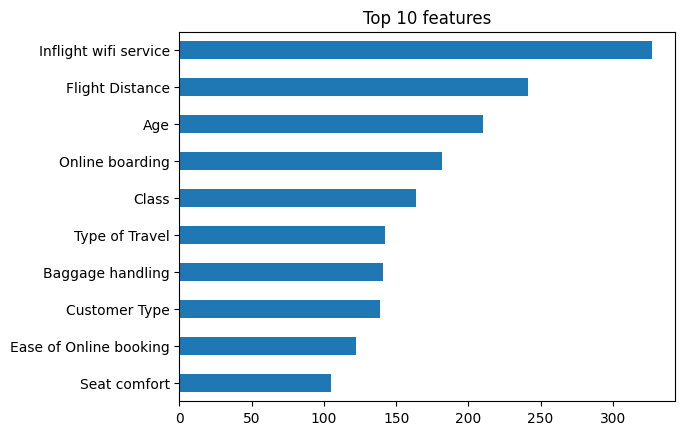

In [44]:
import matplotlib.pyplot as plt
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()  # how much each column was used, smallest to largest
importance.tail(10).plot.barh(title="Top 10 features");  # bar chart of the 10 biggest

## 6. Make a submission
Submissions are **probabilities**, not 0/1 labels.

In [45]:
submission = pd.DataFrame({  # build the file Kaggle expects
    "id": test["id"],  # which row each prediction is for
    "satisfaction": model.predict_proba(X_test)[:, 1],  # predicted probability of being satisfied
})
submission.to_csv("submission.csv", index=False)  # save as csv (index=False avoids an extra column)
submission.head()  # check the first 5 rows

,id,satisfaction
0,699635,0.240544
1,699636,0.920363
2,699637,0.874247
3,699638,0.039788
4,699639,0.044582


## Ideas to try next
- Train on **all** the data for the final model (we left 20% out)
- Add features, e.g. the average of all the service ratings
- Use cross-validation instead of one split
- Try CatBoost or XGBoost
- Tune `n_estimators`, `learning_rate`, `num_leaves`

Change **one thing at a time** and see if the validation AUC goes up.